# Regresión Lineal Múltiple vs Regresión Polinomial
### Dataset: Ventas semanales de Walmart (45 tiendas)

**Pregunta:** ¿Puede la Regresión Lineal Múltiple aproximar las ventas igual de bien que la Polinomial?

Vamos a entrenar ambos modelos con los mismos datos y comparar sus métricas.

In [1]:
# ============================================================
# 1. IMPORTAR LIBRERÍAS
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
# ============================================================
# 2. CARGAR Y PREPARAR DATOS
# ============================================================
# extraer mes y semana de la columna Date, luego descartarla.

df = pd.read_csv("Walmart.csv")

df['Date']  = pd.to_datetime(df['Date'], dayfirst=True)
df['month'] = df['Date'].dt.month
df['week']  = df['Date'].dt.isocalendar().week.astype(int)
df = df.drop(columns=['Date'])

print("Dataset listo. Columnas:", df.columns.tolist())
print("Registros:", len(df))

Dataset listo. Columnas: ['Store', 'Weekly_Sales', 'Holiday_Flag', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'month', 'week']
Registros: 6435


In [3]:
# ============================================================
# 3. CORRELACIÓN DE PEARSON
# ============================================================
# Recordatorio de qué tan relacionada está cada variable con las ventas.

features = ['Store', 'Holiday_Flag', 'Temperature',
            'Fuel_Price', 'CPI', 'Unemployment', 'month', 'week']

correlacion = (df[features + ['Weekly_Sales']]
               .corr()['Weekly_Sales']
               .drop('Weekly_Sales')
               .sort_values(key=abs, ascending=False))

print("Correlación con Weekly_Sales:")
print("=" * 45)
for col, val in correlacion.items():
    barra = '█' * int(abs(val) * 40)
    signo = '+' if val >= 0 else '-'
    print(f"{col:<15} {signo}{abs(val):.3f}  {barra}")

print("\n→ Todas las correlaciones son bajas (máx ~0.33).")
print("  Esto ya nos da una pista de que el modelo lineal va a luchar más.")

Correlación con Weekly_Sales:
Store           -0.335  █████████████
Unemployment    -0.106  ████
month           +0.076  ███
week            +0.074  ██
CPI             -0.073  ██
Temperature     -0.064  ██
Holiday_Flag    +0.037  █
Fuel_Price      +0.009  

→ Todas las correlaciones son bajas (máx ~0.33).
  Esto ya nos da una pista de que el modelo lineal va a luchar más.


In [ ]:
# ============================================================
# 4. SELECCIONAR X e y — NORMALIZAR — DIVIDIR
# ============================================================

X = df[features].values
y = df['Weekly_Sales'].values

# Guardar rangos para desnormalizar después
X_min, X_max = X.min(axis=0), X.max(axis=0)
y_min, y_max = y.min(), y.max()

# Normalizar
X_norm = (X - X_min) / (X_max - X_min)
y_norm = (y - y_min) / (y_max - y_min)

# Dividir 80/20 — mismo random_state para comparación justa
X_train, X_test, y_train, y_test = train_test_split(
    X_norm, y_norm, test_size=0.2, random_state=42
)

print(f"Entrenamiento: {X_train.shape[0]} | Prueba: {X_test.shape[0]}")

Entrenamiento: 5148 | Prueba: 1287


In [9]:
# ============================================================
# 5A. MODELO 1 — REGRESIÓN LINEAL MÚLTIPLE
# ============================================================
# Igual al ejercicio del seguro médico.
# Busca una relación RECTA entre las variables y las ventas:
#   ventas = w1*Store + w2*Holiday + w3*Temp + ... + b

modelo_lineal = LinearRegression()
modelo_lineal.fit(X_train, y_train)

pred_lineal = modelo_lineal.predict(X_test)

r2_lin  = r2_score(y_test, pred_lineal)
mae_lin = mean_absolute_error(y_test, pred_lineal)
mse_lin = mean_squared_error(y_test, pred_lineal)
mae_lin_real = mae_lin * (y_max - y_min)   # en dólares reales

print("── Coeficientes Regresión Lineal ──")
for nombre, coef in zip(features, modelo_lineal.coef_):
    impacto = '↑' if coef > 0 else '↓'
    print(f"  {nombre:<15}: {coef:>8.4f}  {impacto}")

print(f"\n  Intercepto: {modelo_lineal.intercept_:.4f}")

print("\n── Métricas Regresión Lineal ──")
print(f"  R²:        {r2_lin:.4f}  ")
print(f"  MAE real:  ${mae_lin_real:,.0f} USD en promedio")
print(f"  MSE:       {mse_lin:.4f}")

── Coeficientes Regresión Lineal ──
  Store          :  -0.1847  ↓
  Holiday_Flag   :   0.0131  ↑
  Temperature    :  -0.0442  ↓
  Fuel_Price     :   0.0056  ↑
  CPI            :  -0.0619  ↓
  Unemployment   :  -0.0645  ↓
  month          :   0.2037  ↑
  week           :  -0.1671  ↓

  Intercepto: 0.3819

── Métricas Regresión Lineal ──
  R²:        0.1542  
  MAE real:  $433,025 USD en promedio
  MSE:       0.0209


In [6]:
# ============================================================
# 5B. MODELO 2 — REGRESIÓN POLINOMIAL (degree=2)
# ============================================================
# Agrega columnas X² al modelo para capturar relaciones curvas.
# Ejemplo: quizás las ventas suben mucho en semanas específicas
# (navidad, black friday) de forma no lineal.

GRADO = 2

modelo_poli = Pipeline([
    ('poly', PolynomialFeatures(degree=GRADO, include_bias=False)),
    ('reg',  LinearRegression())
])
modelo_poli.fit(X_train, y_train)

pred_poli = modelo_poli.predict(X_test)

r2_pol  = r2_score(y_test, pred_poli)
mae_pol = mean_absolute_error(y_test, pred_poli)
mse_pol = mean_squared_error(y_test, pred_poli)
mae_pol_real = mae_pol * (y_max - y_min)

print(f"── Métricas Regresión Polinomial (degree={GRADO}) ──")
print(f"  R²:        {r2_pol:.4f}  → explica el {r2_pol*100:.1f}% de la variación")
print(f"  MAE real:  ${mae_pol_real:,.0f} USD en promedio")
print(f"  MSE:       {mse_pol:.4f}")

── Métricas Regresión Polinomial (degree=2) ──
  R²:        0.3064  → explica el 30.6% de la variación
  MAE real:  $388,994 USD en promedio
  MSE:       0.0172


In [7]:
# ============================================================
# 6. COMPARACIÓN DIRECTA
# ============================================================

print("="*55)
print(f"{'Modelo':<25} {'R²':>8} {'MAE real':>15}")
print("-"*55)
print(f"{'Lineal Múltiple':<25} {r2_lin:>8.4f} ${mae_lin_real:>13,.0f}")
print(f"{'Polinomial degree=2':<25} {r2_pol:>8.4f} ${mae_pol_real:>13,.0f}")
print("="*55)

mejora_r2  = (r2_pol - r2_lin) / r2_lin * 100
mejora_mae = (mae_lin_real - mae_pol_real) / mae_lin_real * 100

print(f"\n→ El polinomial mejora el R² en {mejora_r2:.1f}%")
print(f"→ El polinomial reduce el error en ${mae_lin_real-mae_pol_real:,.0f} USD ({mejora_mae:.1f}%)")
print("\n¿Por qué la lineal no alcanza?")
print("  Las ventas no crecen de forma proporcional con cada variable.")
print("  Hay efectos combinados (ej: feriado + diciembre = mucho más ventas)")
print("  que una línea recta no puede capturar, pero una curva sí.")

Modelo                          R²        MAE real
-------------------------------------------------------
Lineal Múltiple             0.1542 $      433,025
Polinomial degree=2         0.3064 $      388,994

→ El polinomial mejora el R² en 98.7%
→ El polinomial reduce el error en $44,031 USD (10.2%)

¿Por qué la lineal no alcanza?
  Las ventas no crecen de forma proporcional con cada variable.
  Hay efectos combinados (ej: feriado + diciembre = mucho más ventas)
  que una línea recta no puede capturar, pero una curva sí.


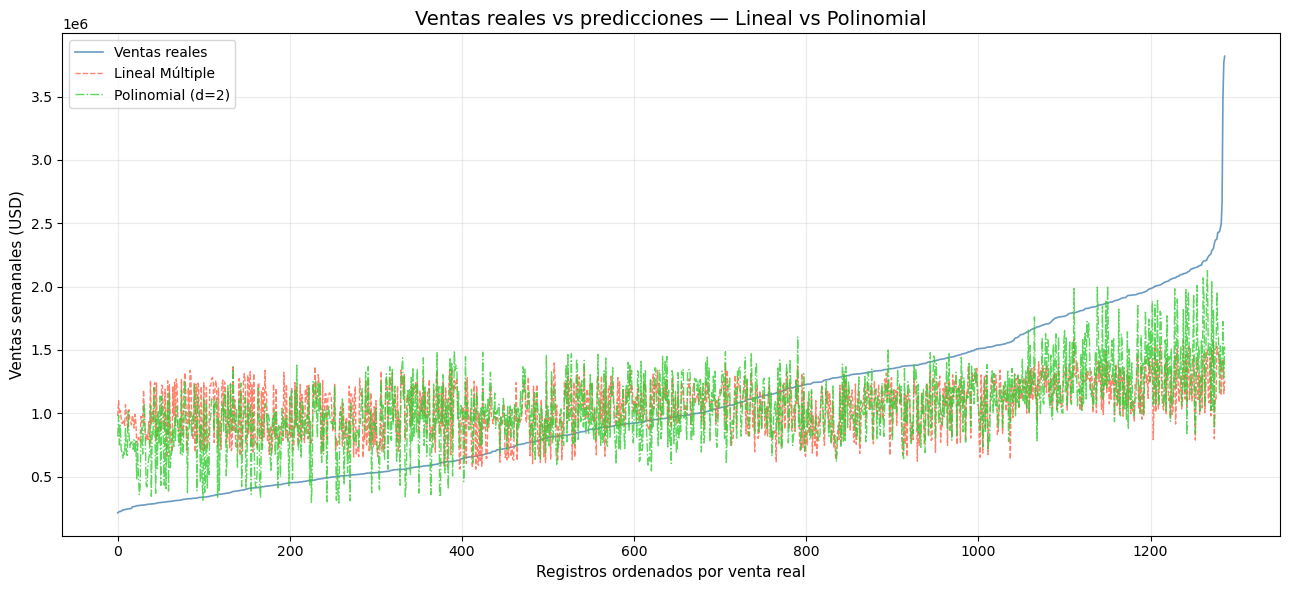

→ Donde la línea verde esté más cerca de la azul, mejor predice el polinomial.
→ La roja (lineal) tiende a quedarse en el centro, sin capturar extremos.


In [8]:
# ============================================================
# 7. GRÁFICA — Real vs Predicción de ambos modelos
# ============================================================

# Desnormalizar para mostrar en dólares reales
y_test_real  = y_test  * (y_max - y_min) + y_min
pred_lin_real = pred_lineal * (y_max - y_min) + y_min
pred_pol_real = pred_poli   * (y_max - y_min) + y_min

# Ordenar por valor real para que la gráfica se vea limpia
idx = np.argsort(y_test_real)
y_ord  = y_test_real[idx]
pl_ord = pred_lin_real[idx]
pp_ord = pred_pol_real[idx]

x_plot = range(len(y_ord))

plt.figure(figsize=(13, 6))
plt.plot(x_plot, y_ord,  color='steelblue', linewidth=1.2, label='Ventas reales',          alpha=0.8)
plt.plot(x_plot, pl_ord, color='tomato',    linewidth=1,   label='Lineal Múltiple',         alpha=0.8, linestyle='--')
plt.plot(x_plot, pp_ord, color='limegreen', linewidth=1,   label=f'Polinomial (d={GRADO})', alpha=0.8, linestyle='-.')

plt.title('Ventas reales vs predicciones — Lineal vs Polinomial', fontsize=14)
plt.xlabel('Registros ordenados por venta real', fontsize=11)
plt.ylabel('Ventas semanales (USD)', fontsize=11)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

print("→ Donde la línea verde esté más cerca de la azul, mejor predice el polinomial.")
print("→ La roja (lineal) tiende a quedarse en el centro, sin capturar extremos.")

In [ ]:
# ============================================================
# 8. PREDECIR CON AMBOS MODELOS — misma tienda, mismos datos
# ============================================================
nuevo = {
    'Store':        1,
    'Holiday_Flag': 0,
    'Temperature':  55.0,
    'Fuel_Price':   3.1,
    'CPI':          211.0,
    'Unemployment': 8.1,
    'month':        3,
    'week':         10
}

X_nuevo      = np.array([[nuevo[f] for f in features]])
X_nuevo_norm = (X_nuevo - X_min) / (X_max - X_min)

pred_l = modelo_lineal.predict(X_nuevo_norm)[0] * (y_max - y_min) + y_min
pred_p = modelo_poli.predict(X_nuevo_norm)[0]   * (y_max - y_min) + y_min

print("============================")
print("PREDICCIÓN — TIENDA 1, SEMANA 10")
print("============================")
print(f"  Regresión Lineal Múltiple : ${pred_l:,.2f} USD")
print(f"  Regresión Polinomial d=2  : ${pred_p:,.2f} USD")
print(f"  Diferencia entre ambas    : ${abs(pred_l - pred_p):,.2f} USD")

---
## 📌 Conclusión — ¿Cuál usar?

| | R² | MAE real | ¿Por qué? |
|---|---|---|---|
| **Lineal Múltiple** | 0.1542 | ~$433,000 | Solo ve relaciones rectas |
| **Polinomial d=2** | 0.3064 | ~$389,000 | Captura curvas y efectos combinados |

**La Regresión Lineal Múltiple SÍ funciona** — y es un punto de partida válido.  
Pero el polinomial lo supera porque las ventas de supermercado tienen  
comportamientos no lineales: picos en feriados, caídas en ciertos meses,  
diferencias enormes entre tiendas grandes y chicas.

Ninguno de los dos llega a un R² muy alto (~0.30) porque este dataset es  
complejo — hay factores que no están en los datos (promociones, clima extremo,  
competencia local) que también afectan las ventas.